#### =============================================================================
#### PROJE: DNA Kodon Dataseti Üzerinde Sınıflandırma
#### MODEL: Bagging Classifier
#### =============================================================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, f1_score
from sklearn.preprocessing import label_binarize
import warnings

#### 1. VERİ YÜKLEME

In [2]:
X_train = pd.read_csv('X_train_processed.csv')
X_test = pd.read_csv('X_test_processed.csv')
y_train = pd.read_csv('y_train_processed.csv').values.ravel()
y_test = pd.read_csv('y_test_processed.csv').values.ravel()
y_names = pd.read_csv('y_test_with_names.csv')

class_mapping = dict(zip(y_names['Kingdom_Encoded'], y_names['Kingdom_Original']))
target_names = [class_mapping[i] for i in sorted(class_mapping.keys())]
n_classes = len(target_names)
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))

#### 2. MODEL EĞİTİMİ (Bagging)

In [3]:
base_estimator = DecisionTreeClassifier(max_depth=15, random_state=42)
bagging_model = BaggingClassifier(
    estimator=base_estimator,
    n_estimators=50,
    max_samples=0.8,
    max_features=0.8,
    random_state=42,
    n_jobs=-1
)

print("\nBagging Modeli egitiliyor...")
bagging_model.fit(X_train, y_train)


Bagging Modeli egitiliyor...


BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=15,
                                                   random_state=42),
                  max_features=0.8, max_samples=0.8, n_estimators=50, n_jobs=-1,
                  random_state=42)

#### 3. TAHMİN VE PERFORMANS

In [4]:
y_pred = bagging_model.predict(X_test)
y_score = bagging_model.predict_proba(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nModel Doğruluğu: %{accuracy*100:.2f}")
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))


Model Doğruluğu: %89.03

Sınıflandırma Raporu:
              precision    recall  f1-score   support

         arc       0.85      0.44      0.58        25
         bct       0.89      0.96      0.92       584
         inv       0.84      0.71      0.77       269
         mam       0.93      0.82      0.87       114
         phg       0.93      0.32      0.47        44
         plm       0.00      0.00      0.00         4
         pln       0.89      0.90      0.90       505
         pri       0.85      0.61      0.71        36
         rod       0.92      0.77      0.84        43
         vrl       0.88      0.97      0.92       567
         vrt       0.91      0.95      0.93       415

    accuracy                           0.89      2606
   macro avg       0.81      0.68      0.72      2606
weighted avg       0.89      0.89      0.88      2606



#### 4. Karmaşıklık Matrisi

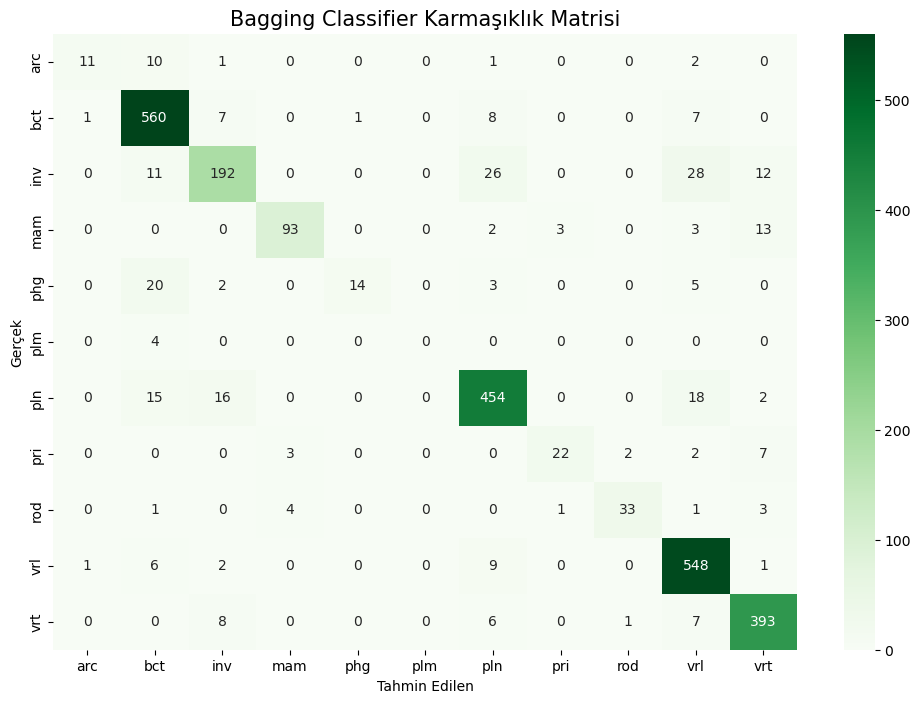

In [5]:
plt.figure(figsize=(12, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('Bagging Classifier Karmaşıklık Matrisi', fontsize=15)
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek')
plt.show()

#### 5. Sınıf Bazlı F1-Skorları

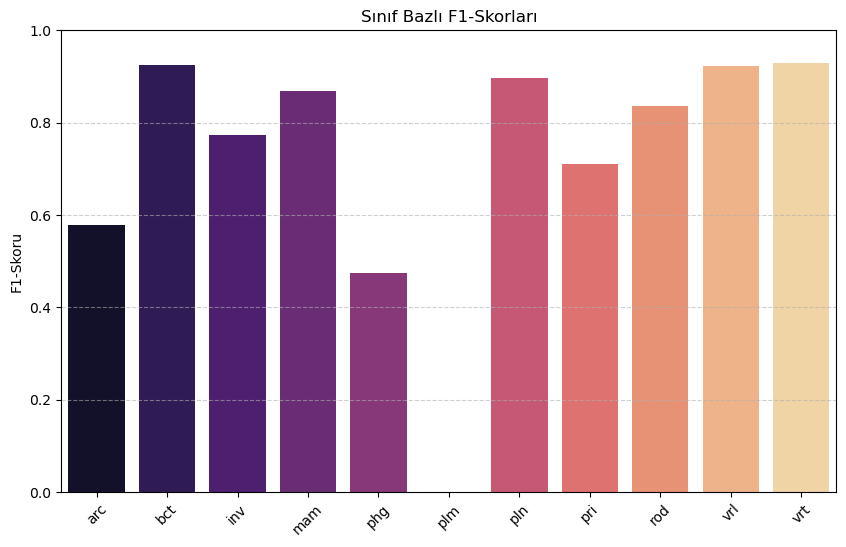

In [6]:
from sklearn.metrics import f1_score
f1_scores = f1_score(y_test, y_pred, average=None)

plt.figure(figsize=(10, 6))
sns.barplot(x=target_names, y=f1_scores, hue=target_names, palette='magma', legend=False)
plt.xticks(rotation=45)
plt.title('Sınıf Bazlı F1-Skorları')
plt.ylabel('F1-Skoru')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

#### 6. Çok Sınıflı ROC Eğrisi

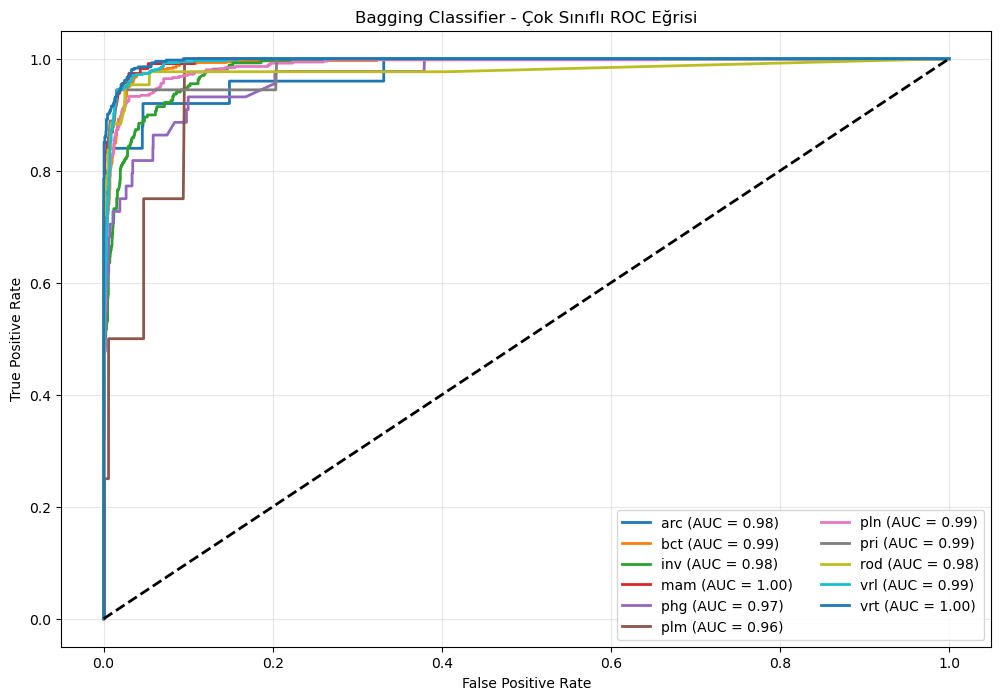

In [7]:
plt.figure(figsize=(12, 8))
for i in range(n_classes):
    # Veri bulunmayan sınıflar için hata kontrolü
    if i in np.unique(y_test):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        plt.plot(fpr, tpr, lw=2, label=f'{target_names[i]} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Bagging Classifier - Çok Sınıflı ROC Eğrisi')
plt.legend(loc="lower right", ncol=2)
plt.grid(alpha=0.3)
plt.show()